<span style="font-size:22px; font-weight:bold">DS5 - NumPy / Pandas / EDA Hackathon — Singapore Talent Market Intelligence</span>

**Team 5 members** Fiona Lim, Cheah Peng Huat (Caleb), Ng Zhenxian, Kevin Chua, Soh Shi Hui

**Persona C — The Government Workforce Planner**

"The Ministry of Manpower wants to know which sectors face structural hiring difficulty so we can target retraining grants."

### Research questions
- Which sectors have the highest hiring difficulty?
- Does position level affect hiring difficulty?
- Which roles have high vacancies but low applicants?
- What are the top 5 hardest-to-fill sectors?





In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [5]:
# Load — this may take 10–15 seconds on the first run
df = pd.read_csv('/home/ssh/SGJobData/SGJobData.csv', low_memory=False)


In [6]:
# Sanity checks
print(df.shape)          # Expect (~1048585, 20)
print(df.dtypes)
print(df.head(3))


(1048585, 22)
categories                                str
employmentTypes                           str
metadata_expiryDate                       str
metadata_isPostedOnBehalf                bool
metadata_jobPostId                        str
metadata_newPostingDate                   str
metadata_originalPostingDate              str
metadata_repostCount                    int64
metadata_totalNumberJobApplication      int64
metadata_totalNumberOfView              int64
minimumYearsExperience                  int64
numberOfVacancies                       int64
occupationId                          float64
positionLevels                            str
postedCompany_name                        str
salary_maximum                          int64
salary_minimum                          int64
salary_type                               str
status_id                               int64
status_jobStatus                          str
title                                     str
average_salary      

In [7]:
df['metadata_originalPostingDate'] = pd.to_datetime(df['metadata_originalPostingDate'])
df['metadata_newPostingDate']       = pd.to_datetime(df['metadata_newPostingDate'])
df['metadata_expiryDate']           = pd.to_datetime(df['metadata_expiryDate'])



In [8]:
# Shape, types, missing values at a glance
print(f"Rows: {df.shape[0]:,}  Columns: {df.shape[1]}")
print("\nNull counts:\n", df.isnull().sum().sort_values(ascending=False).head(10))
print("\nBasic stats:\n", df[['salary_minimum','salary_maximum','average_salary',
                               'minimumYearsExperience','numberOfVacancies']].describe())


Rows: 1,048,585  Columns: 22

Null counts:
 occupationId                    1048585
categories                         3988
metadata_expiryDate                3988
metadata_jobPostId                 3988
metadata_newPostingDate            3988
employmentTypes                    3988
status_jobStatus                   3988
metadata_originalPostingDate       3988
positionLevels                     3988
postedCompany_name                 3988
dtype: int64

Basic stats:
        salary_minimum  salary_maximum  average_salary  minimumYearsExperience  \
count    1.048585e+06    1.048585e+06    1.048585e+06            1.048585e+06   
mean     3.815312e+03    5.723578e+03    4.769445e+03            2.779573e+00   
std      3.172182e+03    5.018387e+04    2.547809e+04            2.537049e+00   
min      0.000000e+00    0.000000e+00    0.000000e+00            0.000000e+00   
25%      2.500000e+03    3.300000e+03    2.900000e+03            1.000000e+00   
50%      3.000000e+03    4.500000e+03    3

In [9]:
# Remove obvious outliers using the 99th percentile
p99 = np.percentile(df['average_salary'].dropna(), 99)
df_clean = df[(df['average_salary'] > 500) & (df['average_salary'] <= p99)].copy()

# Use NumPy to compute stats on the cleaned array
sal = df_clean['average_salary'].to_numpy()
print(f"Mean: {np.mean(sal):,.0f}  Median: {np.median(sal):,.0f}  Std: {np.std(sal):,.0f}")
print(f"25th pct: {np.percentile(sal, 25):,.0f}  75th pct: {np.percentile(sal, 75):,.0f}")


Mean: 4,551  Median: 3,800  Std: 2,533
25th pct: 2,900  75th pct: 5,500


In [10]:
salary_by_level = (
    df_clean
    .groupby('positionLevels')['average_salary']
    .agg(['mean', 'median', 'count'])
    .rename(columns={'mean': 'avg_salary', 'median': 'median_salary', 'count': 'num_jobs'})
    .sort_values('median_salary', ascending=False)
)
print(salary_by_level)


                    avg_salary  median_salary  num_jobs
positionLevels                                         
Senior Management  9166.091606         8750.0     19644
Middle Management  7017.119383         6300.0     25925
Professional       6647.986773         6000.0    108489
Manager            6605.116159         6000.0    108347
Senior Executive   5586.637209         5000.0     99636
Executive          4119.707783         3750.0    252595
Junior Executive   3380.171451         3150.0    166809
Non-executive      3000.358858         2750.0    129472
Fresh/entry level  2793.007436         2600.0    115659


In [11]:
import re

def extract_first_category(cat_str):
    """Extract the first category label from the JSON-like string."""
    if pd.isna(cat_str):
        return np.nan
    match = re.search(r'"category"\s*:\s*"([^"]+)"', str(cat_str))
    return match.group(1) if match else np.nan

df_clean['primary_category'] = df_clean['categories'].apply(extract_first_category)
print(df_clean['primary_category'].value_counts().head(10))


primary_category
Admin / Secretarial                 101660
Engineering                          99050
Information Technology               97682
Accounting / Auditing / Taxation     77696
Building and Construction            73640
Customer Service                     63867
F&B                                  58830
Logistics / Supply Chain             44039
Banking and Finance                  44033
Sales / Retail                       36604
Name: count, dtype: int64


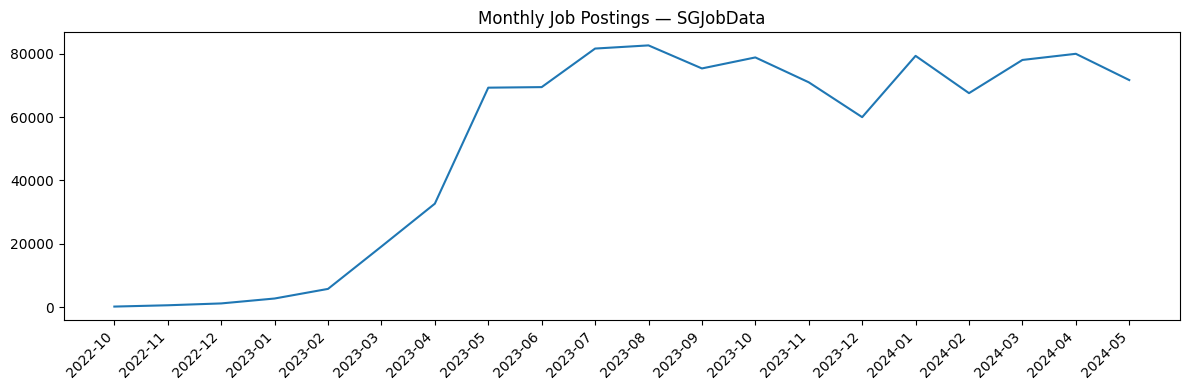

In [12]:
df_clean['year_month'] = df_clean['metadata_originalPostingDate'].dt.to_period('M')
monthly = df_clean.groupby('year_month').size().reset_index(name='postings')

plt.figure(figsize=(12, 4))
plt.plot(monthly['year_month'].astype(str), monthly['postings'])
plt.xticks(rotation=45, ha='right')
plt.title('Monthly Job Postings — SGJobData')
plt.tight_layout()
plt.show()


In [13]:
agency_keywords = ['RECRUIT', 'HR ADVISORY', 'MANPOWER', 'STAFFING', 'CONSULT', 'TALENT']
pattern = '|'.join(agency_keywords)

direct_only = df_clean[
    (~df_clean['postedCompany_name'].str.upper().str.contains(pattern, na=False)) &
    (df_clean['metadata_isPostedOnBehalf'] == False)
]


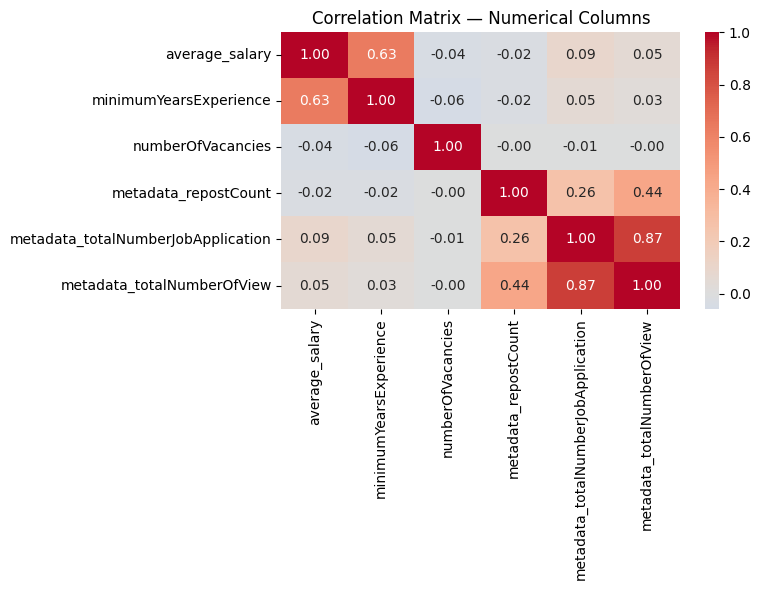

In [14]:
num_cols = ['average_salary', 'minimumYearsExperience', 'numberOfVacancies',
            'metadata_repostCount', 'metadata_totalNumberJobApplication',
            'metadata_totalNumberOfView']
corr = df_clean[num_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix — Numerical Columns')
plt.tight_layout()
plt.show()


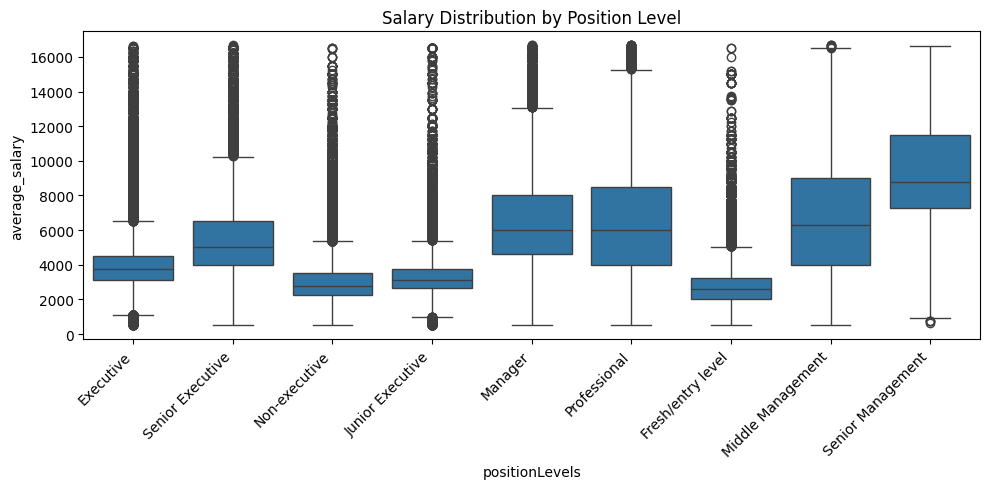

In [15]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_clean, x='positionLevels', y='average_salary')
plt.xticks(rotation=45, ha='right')
plt.title('Salary Distribution by Position Level')
plt.tight_layout()
plt.show()



In [16]:
#1. What is the shape of the DataFrame, the date range of metadata_originalPostingDate, and how many unique job post IDs are there?
print(df_clean.shape)
print(df_clean['metadata_originalPostingDate'].min(), df_clean['metadata_originalPostingDate'].max())
print(df_clean['metadata_jobPostId'].nunique())
# print("Unique Job Post IDs:", df_clean['metadata_jobPostId'].unique()) 
# this will print all unique job post IDs, which may be a very long list. 
#Consider printing only the count or a sample if there are too many.

(1026576, 24)
2022-10-03 00:00:00 2024-05-29 00:00:00
1026576


In [17]:
#2. What are the top 10 most common primary_category values, and 
#what percentage of all jobs does each represent? (Use .value_counts(normalize=True))

counts=df_clean['primary_category'].value_counts().head(10)

# 2. Get the percentage (normalize=True gives a 0-1 decimal, so we multiply by 100)
percentages = df_clean['primary_category'].value_counts(normalize=True).head(10) * 100

Top_10_most_common_categories = pd.DataFrame({"Count": counts,
                                              "Percentage": percentages})
print(Top_10_most_common_categories)

                                   Count  Percentage
primary_category                                    
Admin / Secretarial               101660    9.902823
Engineering                        99050    9.648579
Information Technology             97682    9.515321
Accounting / Auditing / Taxation   77696    7.568461
Building and Construction          73640    7.173361
Customer Service                   63867    6.221361
F&B                                58830    5.730701
Logistics / Supply Chain           44039    4.289892
Banking and Finance                44033    4.289307
Sales / Retail                     36604    3.565640


In [18]:
#3. After removing salary outliers, what is the median average_salary broken down by positionLevels? 
# #Sort from highest to lowest.

salary_by_level = (
    df_clean
    .groupby('positionLevels')['average_salary']
    .agg(['mean', 'median', 'count'])
    .rename(columns={'mean': 'avg_salary', 'median': 'median_salary', 'count': 'num_jobs'})
    .sort_values('median_salary', ascending=False)
)
print(salary_by_level)


                    avg_salary  median_salary  num_jobs
positionLevels                                         
Senior Management  9166.091606         8750.0     19644
Middle Management  7017.119383         6300.0     25925
Professional       6647.986773         6000.0    108489
Manager            6605.116159         6000.0    108347
Senior Executive   5586.637209         5000.0     99636
Executive          4119.707783         3750.0    252595
Junior Executive   3380.171451         3150.0    166809
Non-executive      3000.358858         2750.0    129472
Fresh/entry level  2793.007436         2600.0    115659


In [19]:
#4. Which 5 columns have the most missing values? What percentage of rows are null in each?
null_counts = df_clean.isnull().sum().sort_values(ascending=False).head(5)
null_percentages = (df_clean.isnull().mean() * 100).sort_values(ascending=False).head(5)
missing_data_summary = pd.DataFrame({
    'Null Count': null_counts,
    'Null Percentage': null_percentages
})
print(missing_data_summary)



                     Null Count  Null Percentage
occupationId            1026576            100.0
categories                    0              0.0
metadata_expiryDate           0              0.0
employmentTypes               0              0.0
metadata_jobPostId            0              0.0


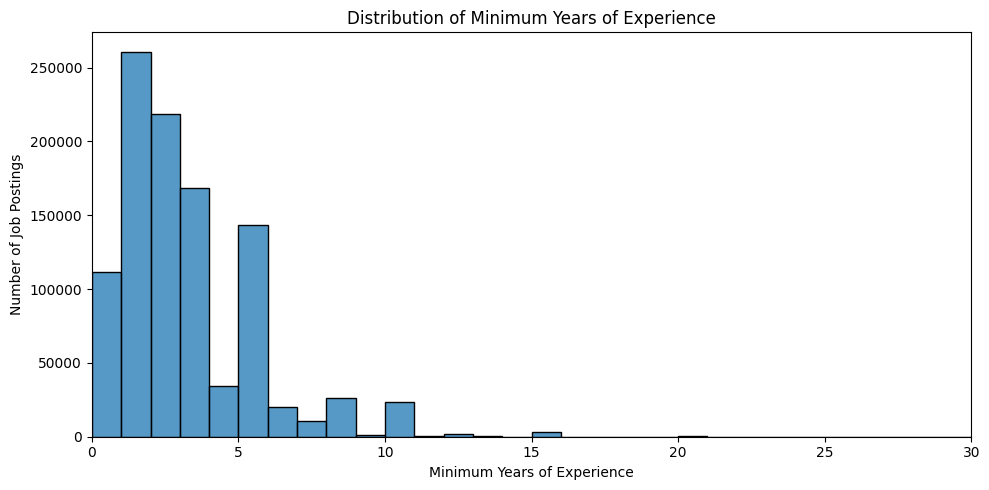

In [20]:
# What is the distribution of minimumYearsExperience? Plot a histogram. Where does the bulk of demand sit?

df_filtered = df_clean[df_clean['minimumYearsExperience'] <= 30] #remove 80-year outliers from calculations entirely
plt.figure(figsize=(10, 5)) #the numbers 10 and 5 represent the width and height of plot in inches.
sns.histplot(df_filtered['minimumYearsExperience'].dropna(), bins=30, kde=False) 
# dropna() removes missing values, bins=30 creates 30 bars, kde=False turns off the density curve.

plt.xlim(0, 30) #sets the limits of the x-axis from 0 to 30 years of experience. Adjust as needed based on data.
plt.title('Distribution of Minimum Years of Experience') #sets the title of the plot.
plt.xlabel('Minimum Years of Experience') #sets the label for the x-axis.
plt.ylabel('Number of Job Postings') #sets the label for the y-axis.
plt.tight_layout() #adjusts the layout to prevent overlap of elements.
plt.show() #displays the plot on the screen.

# The bulk of demand sits between 0-5 years of experience, with a significant drop-off after 10 years. 

In [21]:
# Compute the correlation between average_salary, minimumYearsExperience, metadata_repostCount, and metadata_totalNumberJobApplication. 
# Which pair has the strongest relationship?

num_cols = ['average_salary', 'minimumYearsExperience', 'metadata_repostCount', 'metadata_totalNumberJobApplication']
corr = df_clean[num_cols].corr()
print(corr)


                                    average_salary  minimumYearsExperience  \
average_salary                            1.000000                0.634887   
minimumYearsExperience                    0.634887                1.000000   
metadata_repostCount                     -0.024838               -0.021163   
metadata_totalNumberJobApplication        0.089786                0.051169   

                                    metadata_repostCount  \
average_salary                                 -0.024838   
minimumYearsExperience                         -0.021163   
metadata_repostCount                            1.000000   
metadata_totalNumberJobApplication              0.258714   

                                    metadata_totalNumberJobApplication  
average_salary                                                0.089786  
minimumYearsExperience                                        0.051169  
metadata_repostCount                                          0.258714  
metadata_totalNu

Persona C — The Government Workforce Planner
"The Ministry of Manpower wants to know which sectors face structural hiring difficulty so we can target retraining grants."

Create a "difficulty score" using NumPy: combine metadata_repostCount, numberOfVacancies, and metadata_totalNumberJobApplication into a single normalised index (hint: (x - x.min()) / (x.max() - x.min())).


**Qn 1 - Which sectors have the highest hiring difficulty based on repost rate, vacancies, and low applications?**

hiring difficulty score = (repost_norm + vacancies_norm + apps_norm) / 3

Results:
Public / Civil Service 0.33509

In [78]:
# 1. Normalize the individual components (0 to 1 scale)
def normalize(col):
    return (col - col.min()) / (col.max() - col.min())

repost_norm = normalize(df_clean['metadata_repostCount'])
vacancies_norm = normalize(df_clean['numberOfVacancies'])
# Inverse normalization for applications: 1 = few apps (difficult), 0 = many apps (easy)
apps_norm = 1 - normalize(df_clean['metadata_totalNumberJobApplication'])

# 2. Combine into a single Difficulty Score (Average of the three)
# You can weight these if you think Reposts are more important than Vacancies
df_clean['hiring_difficulty_score'] = (repost_norm + vacancies_norm + apps_norm) / 3




**QN 2 - Does Position Level Affect Difficulty?**

Answer: Yes. Lower-level roles such as Non-executive and Fresh/entry level have higher difficulty scores than management roles. 

This suggests hiring difficulty is not only a senior-skills issue; it also affects frontline and entry-level manpower needs.

In [79]:
# Which categories and position levels have the highest difficulty scores?

# 3. View the sectors with the highest structural difficulty
difficulty_by_primary_category= df_clean.groupby('primary_category')['hiring_difficulty_score'].mean().sort_values(ascending=False)
difficulty_by_position_level = df_clean.groupby('positionLevels')['hiring_difficulty_score'].mean().sort_values(ascending=False)

print(difficulty_by_primary_category.head(10).round(4),"\n" + "="*50)
print(difficulty_by_position_level.head(10).round(4))



primary_category
Public / Civil Service            0.3509
Hospitality                       0.3494
Engineering                       0.3483
Customer Service                  0.3460
Healthcare / Pharmaceutical       0.3459
Design                            0.3455
Security and Investigation        0.3455
Precision Engineering             0.3451
Architecture / Interior Design    0.3447
Education and Training            0.3446
Name: hiring_difficulty_score, dtype: float64 
positionLevels
Non-executive        0.3454
Fresh/entry level    0.3446
Executive            0.3426
Senior Executive     0.3426
Junior Executive     0.3421
Manager              0.3409
Professional         0.3404
Middle Management    0.3398
Senior Management    0.3386
Name: hiring_difficulty_score, dtype: float64


make the table more readable 
1. Convert the Series results into DataFrames
df_sector_difficulty = difficulty_by_primary_category.head(10).reset_index()
df_level_difficulty = difficulty_by_position_level.head().reset_index()

2. Rename the columns so they look professional (optional)
df_sector_difficulty.columns = ['Primary Category', 'Difficulty Score']
df_level_difficulty.columns = ['Position Level', 'Difficulty Score']

3. Print them (Pandas will now format them as tables)
print("TOP 10 DIFFICULT SECTORS")
print(df_sector_difficulty)
print("\n" + "="*50 + "\n")

print("DIFFICULTY BY POSITION LEVEL")
print(df_level_difficulty)

**Qn 3 - Are there roles with many vacancies but few applicants (supply–demand mismatch)?**
General management

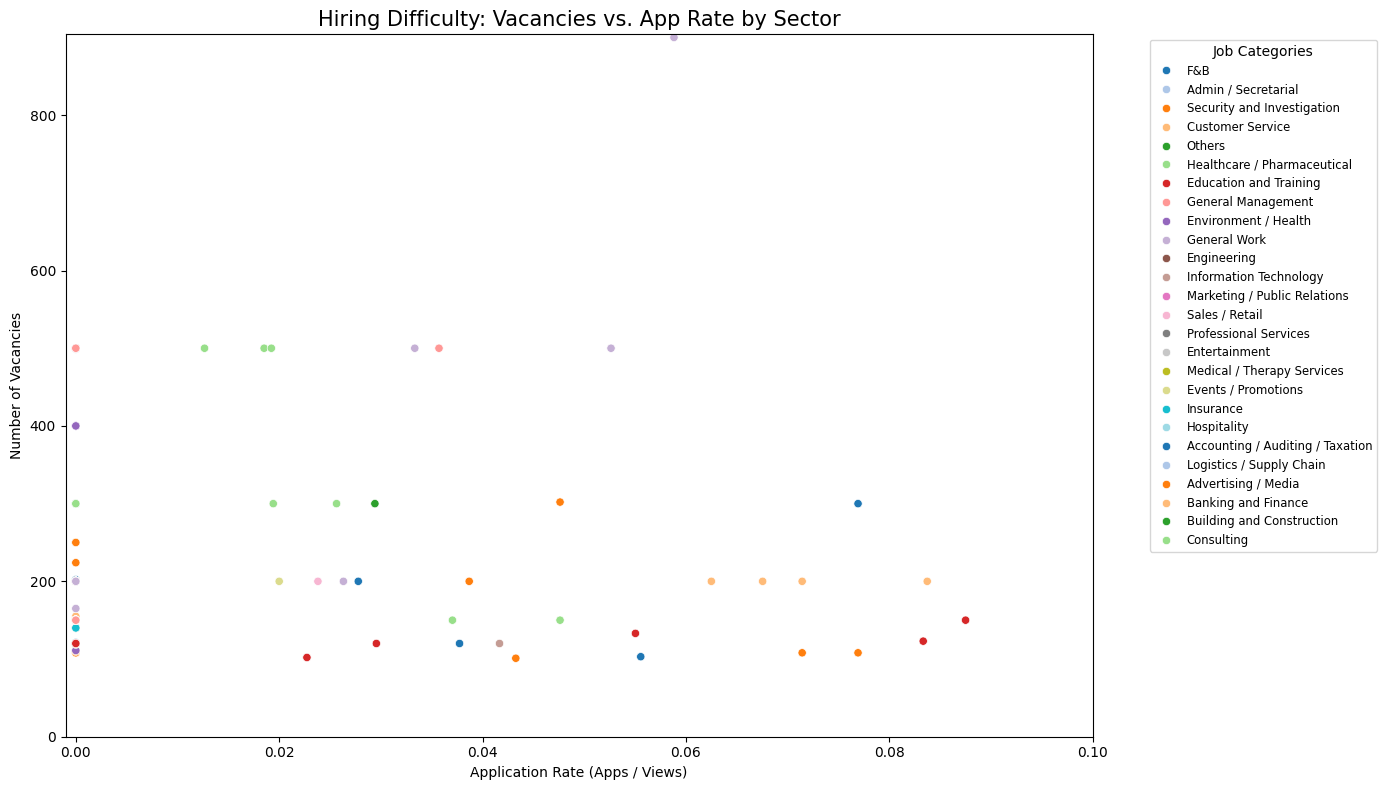

In [69]:
# Are there roles with high vacancy counts but very low application rates (applications ÷ views)? Visualise with a scatter plot.


# 1. Calculate Application Rate (Apps / Views). This metric tells us what percentage of people who saw the job actually clicked "Apply."
# We add a tiny epsilon or use fillna to avoid division by zero
df_clean['app_rate'] = df_clean['metadata_totalNumberJobApplication'] / df_clean['metadata_totalNumberOfView']

# Replace infinite values (from division by zero) or NaNs with 0
df_clean['app_rate'] = df_clean['app_rate'].replace([np.inf, -np.inf], np.nan).fillna(0)

# 2. Filter for high vacancy roles to keep the plot clean
# jobs with more than 100 vacancies
high_vacancy_df = df_clean[df_clean['numberOfVacancies'] > 100].copy()

# 3. Scatter plot: Vacancies vs Application Rate
plt.figure(figsize=(14,8))

# 1. Add hue to color dots by category
# We remove the 'color' argument because 'hue' will now control the colors
ax = sns.scatterplot(
    data=high_vacancy_df, 
    x='app_rate', 
    y='numberOfVacancies',
    hue='primary_category', 
    alpha=1,
    palette='tab20' # A professional color palette
)

# 2. Limit the view to the 'Problem Zone' (0% to 10% app rate & vacancies >100)
plt.xlim(-0.001, 0.10)
plt.ylim(0, high_vacancy_df['numberOfVacancies'].max()-100 + 5)

# 3. Move the legend outside the plot so it doesn't cover the data
plt.legend(title='Job Categories', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')

plt.title('Hiring Difficulty: Vacancies vs. App Rate by Sector', fontsize=15)
plt.xlabel('Application Rate (Apps / Views)')
plt.ylabel('Number of Vacancies')

plt.tight_layout() # Essential when moving legends outside
plt.show()

**Qn 4 - Top 5 Hardest to Fill Sectors**

Plot monthly metadata_repostCount trends by category for the top 5 hard-to-fill sectors.

The Strategy
Identify the Top 5: We use the hiring_difficulty_score we calculated earlier.
Filter & Resample: We filter the data and group it by Month.
Plot: Use a line chart to show which sectors are seeing an increase in reposting (indicating growing structural difficulty).

In [ ]:
# 1. Identify the Top 5 Hardest-to-Fill Sectors
top_5_sectors = (
    df_clean.groupby('primary_category')['hiring_difficulty_score']
    .mean()
    .sort_values(ascending=False)
    .head(5)
    .index.tolist()
)

# 2. Filter the dataframe for only these sectors
df_top_5 = df_clean[df_clean['primary_category'].isin(top_5_sectors)].copy()


# 3. Group by Sector AND Month, then sum the reposts
# 'MS' stands for Month Start
trends = (
    df_top_5.groupby(['primary_category', pd.Grouper(key='metadata_originalPostingDate', freq='MS')])
    ['metadata_repostCount']
    .sum()
    .reset_index()
)



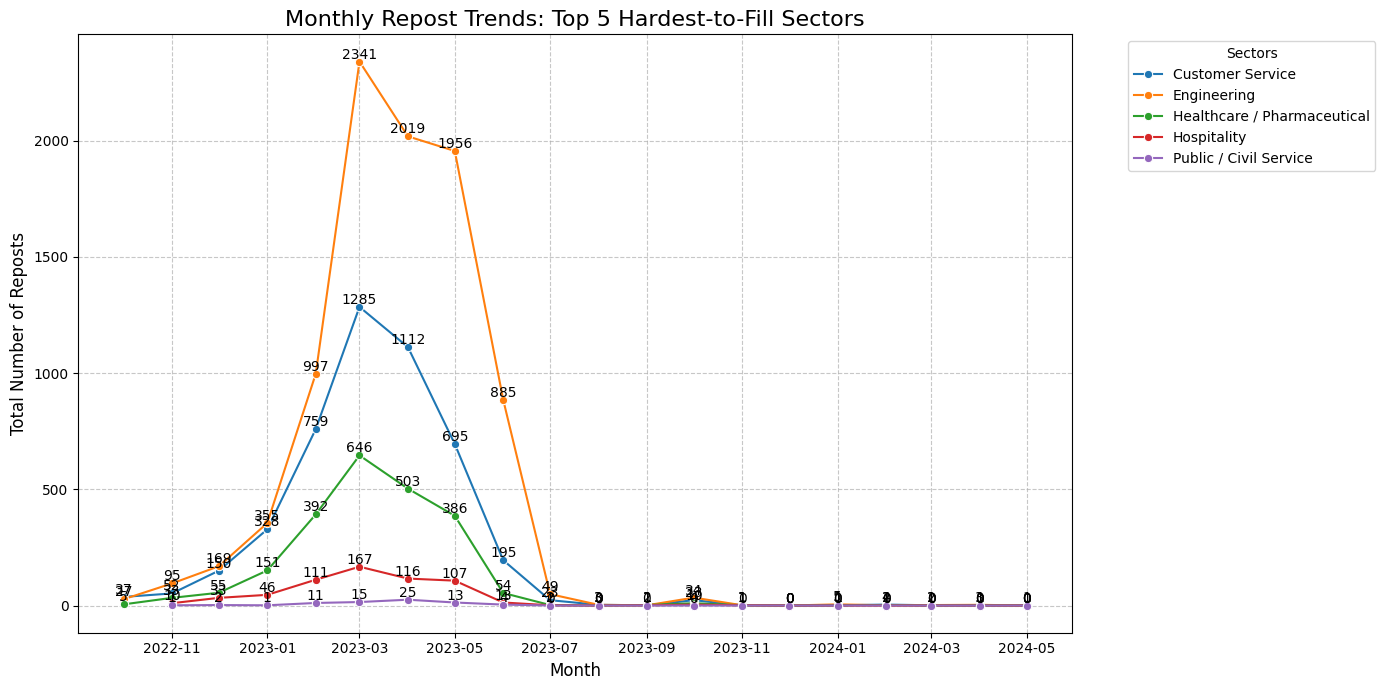

In [73]:
# 4. Visualise with a Line Plot
plt.figure(figsize=(14, 7))
sns.lineplot(
    data=trends, 
    x='metadata_originalPostingDate', 
    y='metadata_repostCount', 
    hue='primary_category', 
    marker='o',
    palette='tab10'
)

for x, y in zip(trends['metadata_originalPostingDate'], trends['metadata_repostCount']):
    plt.text(x, y, y, ha='center', va='bottom')


# Formatting for a professional report
plt.title('Monthly Repost Trends: Top 5 Hardest-to-Fill Sectors', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Number of Reposts', fontsize=12)
plt.legend(title='Sectors', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()